In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import json

from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator, LogLocator, NullFormatter, FormatStrFormatter
from matplotlib.colors import to_rgb

with open("matplotlibrc.json") as f:
    mpl.rcParams.update(json.load(f))

def lighten(c, amount):
    """Blend color c toward white; amount=0 -> c, amount=1 -> white."""
    r, g, b = to_rgb(c)
    return (1 - amount) * r + amount, (1 - amount) * g + amount, (1 - amount) * b + amount

In [3]:
def load_ler_csv(csv_path: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path, dtype={"clifford_deformation": str})
    df["ler"] = df["alpha"] / (df["alpha"] + df["beta"])
    df["ler_var"] = df["alpha"] * df["beta"] / (df["alpha"] + df["beta"]) / (df["alpha"] + df["beta"]) / (df["alpha"] + df["beta"] + 1)
    df["ler_unc"] = np.sqrt(df["ler_var"])
    return df

In [25]:
# Okabe-Ito hues, so identity never rests on colour alone: the method sets the
# colour and p_search the dash pattern. The pair clears dE >= 8 under
# protan/deutan/tritan simulation; the default C0/C1 blue/orange does not.
EBBI_COLOR = "#0072B2"  # blue
RS_COLOR = "#D55E00"  # vermillion

def plot_results(used_CD_folder_name: str, method_folder_names: dict, references: dict, xmin: float, xmax: float, y_power: int, ymin: float=None, ymax: float=None, shade: bool = False, y_increments: float = .4, xlabel=True, ylabel=True, references_text=True, figsize=(3.4, 1.5)):
    lers = load_ler_csv(f"../results/brute_force/{used_CD_folder_name}/results.csv").sort_values("ler").reset_index(drop=True).reset_index(drop=False).set_index("clifford_deformation")
    xx = np.logspace(np.log10(xmin), np.log10(xmax), 1000)
    y_factor = 10 ** (-y_power)

    fig, ax = plt.subplots(figsize=figsize)

    # Plot the data sets
    final_cd = {}
    for method_name, (method_folder_name, color, linestyle) in method_folder_names.items():
        df = pd.read_csv(f"../results/{method_folder_name}/checkpoints.csv", dtype={"clifford_deformation": str})
        df["ler"] = df["clifford_deformation"].map(lers["ler"])
        unique = df["source_file"].unique()
        zz = np.zeros((len(unique), xx.size))
        final_cd[method_name] = {} # CD: (count, true_ler)
        for i, entry in enumerate(unique):
            print(f"Processing {method_name} ({i+1}/{len(unique)})..."+10*" ", end="\r")
            sdf = df[(df["source_file"] == entry)].copy()
            sdf["true_ler"] = sdf["clifford_deformation"].map(lers["ler"])
            mask2d = (sdf["method_shots"].values[:, None] < xx[None, :])
            indexes = mask2d.sum(axis=0) - 1
            zz[i, :] = np.where(indexes >= 0, sdf["true_ler"].values[indexes], np.nan)
            cd = sdf["clifford_deformation"].values[indexes][-1]
            final_cd[method_name][cd] = (
                final_cd[method_name].get(cd, [0, None])[0] + 1,
                sdf["true_ler"].values[indexes][-1]
            )
        print()
        median = np.median(zz, axis=0)
        mask = np.isnan(median)
        ax.plot(xx, y_factor * median, linestyle, lw=0.8, label=method_name, color=color, zorder=3)
        if shade:
            # 100% fill
            minimum = np.where(mask, np.nan, np.nanmin(zz, axis=0))
            maximum = np.where(mask, np.nan, np.nanmax(zz, axis=0))
            ax.fill_between(xx, y_factor * minimum, y_factor * maximum, color=color, alpha=0.1, linewidth=0, zorder=2)
            # 60% fill
            lower = np.where(mask, np.nan, np.nanpercentile(zz, 20, axis=0))
            upper = np.where(mask, np.nan, np.nanpercentile(zz, 80, axis=0))
            # ax.fill_between(xx, y_factor * lower, y_factor * upper, color=color, alpha=0.2, linewidth=0, zorder=2, hatch="///")
            ax.fill_between(xx, y_factor * lower, y_factor * upper,
                color=color, alpha=0.2, linewidth=0, zorder=2)
            ax.fill_between(xx, y_factor * lower, y_factor * upper,
                facecolor="none", edgecolor=lighten(color, 0.4),
                linewidth=0, hatch="////", zorder=2)

    # Plot the references
    for name, ler in references.items():
        ler = lers.loc[ler, "ler"]
        ax.axhline(y_factor * ler, color="0.45", linestyle="--", linewidth=0.6, zorder=1)
        ax.text(xmax, y_factor * ler, f" {name}", va='center', ha='left', fontsize=6, zorder=1, color='0.45' if references_text else 'white')

    # Finalize the plot
    ax.set_ylim(ymin, ymax)
    ax.set_xlim(xmin, xmax)
    ax.set_xscale("log")
    ax.set_xlabel("Shots" if xlabel else " ")
    ax.set_ylabel("$P_L$" if ylabel else " ")
    # the y axis carries a factor y_factor, so state the multiplier above the frame
    ax.text(0.0, 1.01, rf"$\times10^{{{y_power}}}$", transform=ax.transAxes, fontsize=6, va='bottom', ha='left')
    ax.yaxis.set_major_locator(MultipleLocator(y_increments))
    # one decimal on every panel: integer labels would be narrower and would let
    # the axes box grow, breaking alignment with the other panels of the figure
    ax.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))
    ax.yaxis.set_minor_locator(MultipleLocator(y_increments / 2))
    ax.xaxis.set_major_locator(LogLocator(base=10.0, subs=(1.0,), numticks=20))
    ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(0.1, 1.0, 0.1), numticks=12))
    ax.xaxis.set_minor_formatter(NullFormatter())
    ax.tick_params(which="both", top=True, right=True)
    return fig, ax


def save_legend(styles: dict, path: str, ncols: int = 6, fontsize: float = 7, **legend_kw):
    """Write the shared legend of the panels to `path` as a standalone PDF.

    `styles` maps the label to (colour, linestyle) and must match what the
    panels were drawn with. The saved page is cropped to the legend itself, so
    it can be dropped into a multi-panel figure at any position; the printed
    size tells you whether `ncols` still fits the column width you are aiming
    for (PRX: 3.4 in single column, 7.0 in double).
    """
    handles = [
        Line2D([], [], color=color, linestyle=linestyle, lw=0.8, label=label)
        for label, (color, linestyle) in styles.items()
    ]
    # layout=None: the global constrained_layout would reserve axes space we do not want
    fig = plt.figure(figsize=(0.1, 0.1), layout=None)
    legend = fig.legend(
        handles=handles, loc="center", ncols=ncols, fontsize=fontsize,
        frameon=False, columnspacing=1.2, handlelength=1.9, handletextpad=0.5,
        labelspacing=0.25, borderaxespad=0.0, **legend_kw,
    )
    fig.canvas.draw()
    w, h = legend.get_window_extent().transformed(fig.dpi_scale_trans.inverted()).size
    fig.savefig(path, transparent=True)
    plt.close(fig)
    print(f"{path}: {ncols} column(s), {w:.2f} x {h:.2f} in")
    return w, h

In [5]:
references_sc3={
    # "XY":    "222222222",
    "CSS":    "000000000",
    "XZZX":   "030303030",
    "B-XZZX": "033000330",
}
references_sc5={
    # "XY":     "2222222222222222222222222",
    "CSS":    "0000000000000000000000000",
    "XZZX":   "0303030303030303030303030",
    "B-XZZX": "0333300300030300030033330",
}

# Main text plots

Processing EBBI: $p_\mathrm{search}=0.1\%$ (25/25)...          
Processing EBBI: $p_\mathrm{search}=0.25\%$ (25/25)...          
Processing EBBI: $p_\mathrm{search}=0.5\%$ (25/25)...          
Processing RS: $p_\mathrm{search}=0.1\%$ (25/25)...          
Processing RS: $p_\mathrm{search}=0.25\%$ (25/25)...          
Processing RS: $p_\mathrm{search}=0.5\%$ (25/25)...          


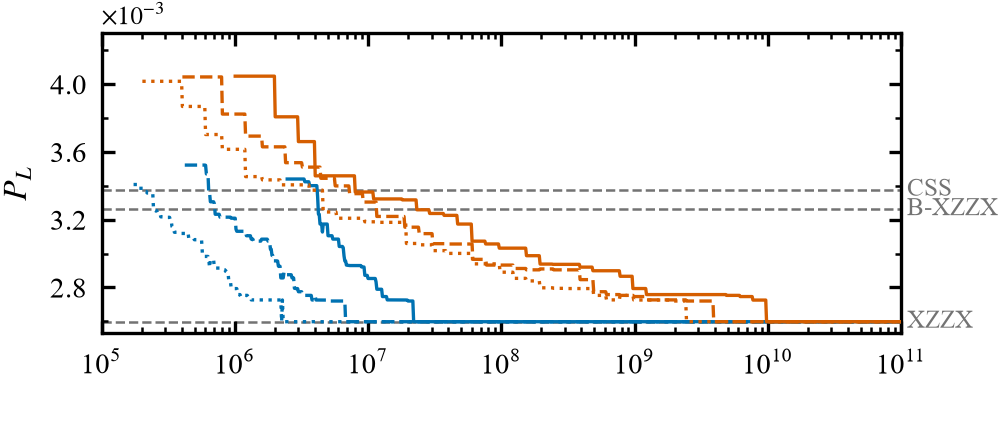

In [30]:
# used_CD_folder_name="used_SC3_HBD"
used_CD_folder_name="all_SC3_HBD"
fig, ax = plot_results(
    used_CD_folder_name=used_CD_folder_name,
    method_folder_names={
        "EBBI: $p_\\mathrm{search}=0.1\\%$": ("ebbi/SC3_HBD_MWPM_1x", EBBI_COLOR, '-'),
        "EBBI: $p_\\mathrm{search}=0.25\\%$": ("ebbi/SC3_HBD_MWPM_2_5x", EBBI_COLOR, '--'),
        "EBBI: $p_\\mathrm{search}=0.5\\%$": ("ebbi/SC3_HBD_MWPM_5x", EBBI_COLOR, ':'),
        "RS: $p_\\mathrm{search}=0.1\\%$": ("rs/SC3_HBD_MWPM_1x", RS_COLOR, '-'),
        "RS: $p_\\mathrm{search}=0.25\\%$": ("rs/SC3_HBD_MWPM_2_5x", RS_COLOR, '--'),
        "RS: $p_\\mathrm{search}=0.5\\%$": ("rs/SC3_HBD_MWPM_5x", RS_COLOR, ':'),
    },
    references=references_sc3,
    xmin=1E5,
    xmax=1E11,
    ymax=4.3,
    ymin=2.53,
    y_power=-3,
    xlabel=False,
)
fig.savefig("outputs/comparizon/SC3_HBD_MWPM.pdf", bbox_inches="tight", transparent=True)
plt.show()

Processing EBBI: $p_\mathrm{search}=0.1\%$ (25/25)...          
Processing EBBI: $p_\mathrm{search}=0.25\%$ (25/25)...          
Processing EBBI: $p_\mathrm{search}=0.5\%$ (25/25)...          
Processing RS: $p_\mathrm{search}=0.1\%$ (25/25)...          
Processing RS: $p_\mathrm{search}=0.25\%$ (25/25)...          
Processing RS: $p_\mathrm{search}=0.5\%$ (25/25)...          


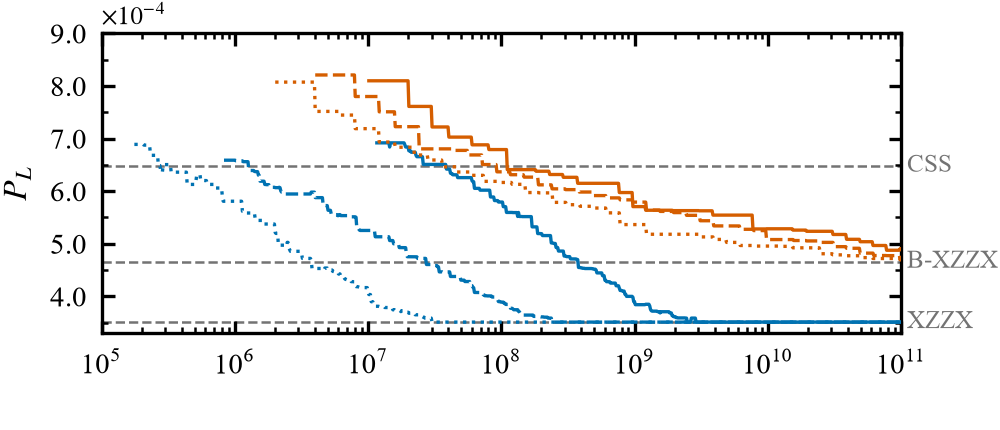

In [31]:
used_CD_folder_name="used_SC5_HBD"
fig, ax = plot_results(
    used_CD_folder_name=used_CD_folder_name,
    method_folder_names={
        "EBBI: $p_\\mathrm{search}=0.1\\%$": ("ebbi/SC5_HBD_MWPM_1x", EBBI_COLOR, '-'),
        "EBBI: $p_\\mathrm{search}=0.25\\%$": ("ebbi/SC5_HBD_MWPM_2_5x", EBBI_COLOR, '--'),
        "EBBI: $p_\\mathrm{search}=0.5\\%$": ("ebbi/SC5_HBD_MWPM_5x", EBBI_COLOR, ':'),
        "RS: $p_\\mathrm{search}=0.1\\%$": ("rs/SC5_HBD_MWPM_1x", RS_COLOR, '-'),
        "RS: $p_\\mathrm{search}=0.25\\%$": ("rs/SC5_HBD_MWPM_2_5x", RS_COLOR, '--'),
        "RS: $p_\\mathrm{search}=0.5\\%$": ("rs/SC5_HBD_MWPM_5x", RS_COLOR, ':'),
    },
    references=references_sc5,
    xmin=1E5,
    xmax=1E11,
    ymax=9,
    ymin=3.3,
    y_power=-4,
    y_increments=1.0,
    xlabel=False,
)
fig.savefig("outputs/comparizon/SC5_HBD_MWPM.pdf", bbox_inches="tight", transparent=True)
plt.show()

Processing EBBI: $p_\mathrm{search}=0.1\%$ (25/25)...          
Processing EBBI: $p_\mathrm{search}=0.25\%$ (25/25)...          
Processing EBBI: $p_\mathrm{search}=0.5\%$ (25/25)...          
Processing RS: $p_\mathrm{search}=0.1\%$ (25/25)...          
Processing RS: $p_\mathrm{search}=0.25\%$ (25/25)...          
Processing RS: $p_\mathrm{search}=0.5\%$ (25/25)...          


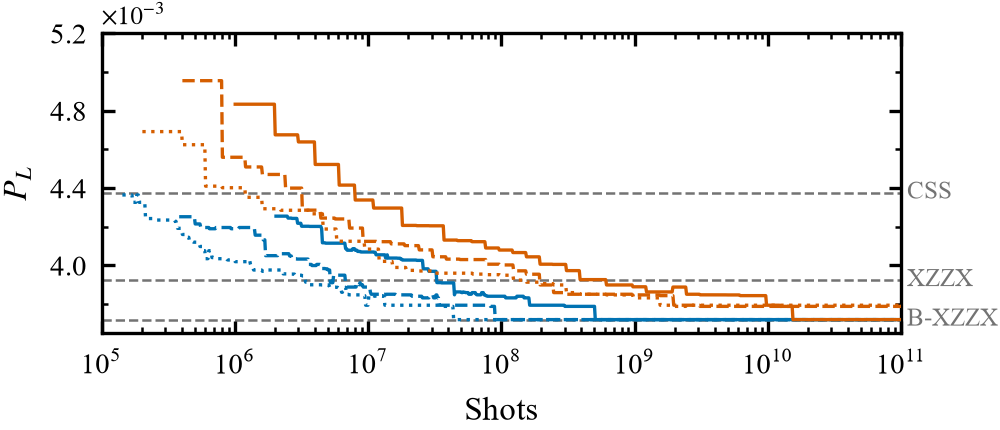

In [32]:
# used_CD_folder_name="used_SC3_MHBD"
used_CD_folder_name="all_SC3_MHBD"
fig, ax = plot_results(
    used_CD_folder_name=used_CD_folder_name,
    method_folder_names={
        "EBBI: $p_\\mathrm{search}=0.1\\%$": ("ebbi/SC3_MHBD_MWPM_1x", EBBI_COLOR, '-'),
        "EBBI: $p_\\mathrm{search}=0.25\\%$": ("ebbi/SC3_MHBD_MWPM_2_5x", EBBI_COLOR, '--'),
        "EBBI: $p_\\mathrm{search}=0.5\\%$": ("ebbi/SC3_MHBD_MWPM_5x", EBBI_COLOR, ':'),
        "RS: $p_\\mathrm{search}=0.1\\%$": ("rs/SC3_MHBD_MWPM_1x", RS_COLOR, '-'),
        "RS: $p_\\mathrm{search}=0.25\\%$": ("rs/SC3_MHBD_MWPM_2_5x", RS_COLOR, '--'),
        "RS: $p_\\mathrm{search}=0.5\\%$": ("rs/SC3_MHBD_MWPM_5x", RS_COLOR, ':'),
    },
    references=references_sc3,
    xmin=1E5,
    xmax=1E11,
    ymax=5.2,
    ymin=3.65,
    y_power=-3,
)
fig.savefig("outputs/comparizon/SC3_MHBD_MWPM.pdf", transparent=True)
plt.show()

Processing EBBI: $p_\mathrm{search}=0.1\%$ (25/25)...          
Processing EBBI: $p_\mathrm{search}=0.25\%$ (25/25)...          
Processing EBBI: $p_\mathrm{search}=0.5\%$ (25/25)...          
Processing RS: $p_\mathrm{search}=0.1\%$ (25/25)...          
Processing RS: $p_\mathrm{search}=0.25\%$ (25/25)...          
Processing RS: $p_\mathrm{search}=0.5\%$ (25/25)...          


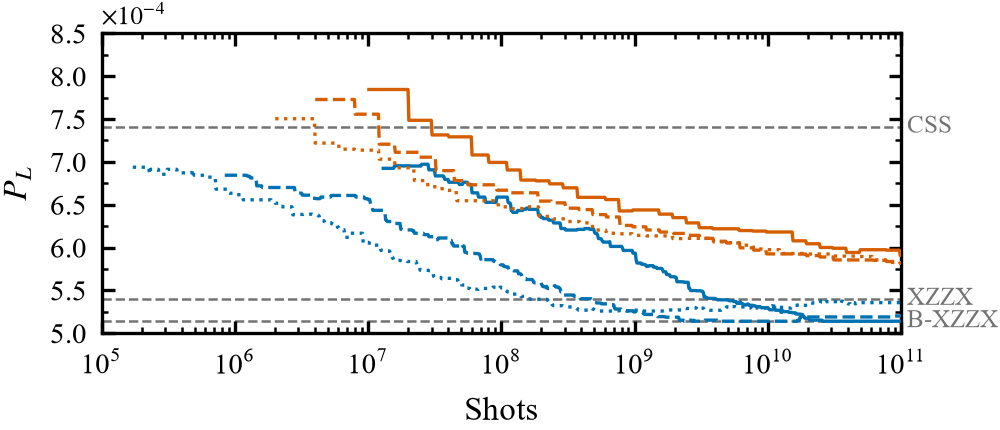

In [33]:
used_CD_folder_name="used_SC5_MHBD"
fig, ax = plot_results(
    used_CD_folder_name=used_CD_folder_name,
    method_folder_names={
        "EBBI: $p_\\mathrm{search}=0.1\\%$": ("ebbi/SC5_MHBD_MWPM_1x", EBBI_COLOR, '-'),
        "EBBI: $p_\\mathrm{search}=0.25\\%$": ("ebbi/SC5_MHBD_MWPM_2_5x", EBBI_COLOR, '--'),
        "EBBI: $p_\\mathrm{search}=0.5\\%$": ("ebbi/SC5_MHBD_MWPM_5x", EBBI_COLOR, ':'),
        "RS: $p_\\mathrm{search}=0.1\\%$": ("rs/SC5_MHBD_MWPM_1x", RS_COLOR, '-'),
        "RS: $p_\\mathrm{search}=0.25\\%$": ("rs/SC5_MHBD_MWPM_2_5x", RS_COLOR, '--'),
        "RS: $p_\\mathrm{search}=0.5\\%$": ("rs/SC5_MHBD_MWPM_5x", RS_COLOR, ':'),
    },
    references=references_sc5,
    xmin=1E5,
    xmax=1E11,
    ymax=8.5,
    ymin=5,
    y_power=-4,
    y_increments=0.5,
)
fig.savefig("outputs/comparizon/SC5_MHBD_MWPM.pdf", transparent=True)
plt.show()

# Appendix plots

In [8]:
figsize=(2.5, 1.5)

Processing EBBI: $p_\mathrm{search}=0.1\%$ (25/25)...          


Processing RS: $p_\mathrm{search}=0.1\%$ (25/25)...          


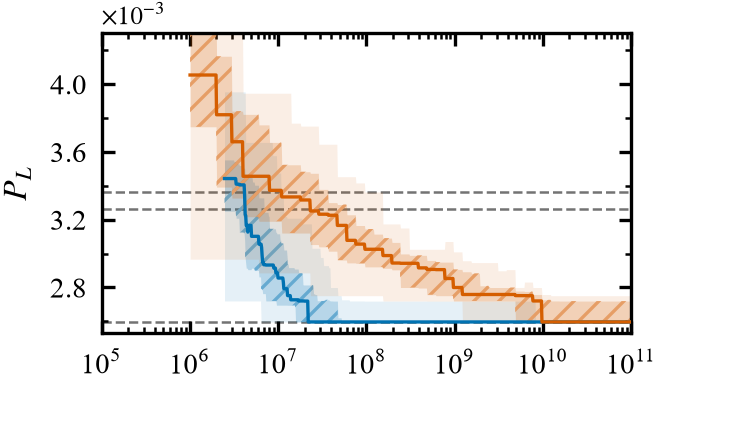

Processing EBBI: $p_\mathrm{search}=0.25\%$ (25/25)...          


Processing RS: $p_\mathrm{search}=0.25\%$ (25/25)...          


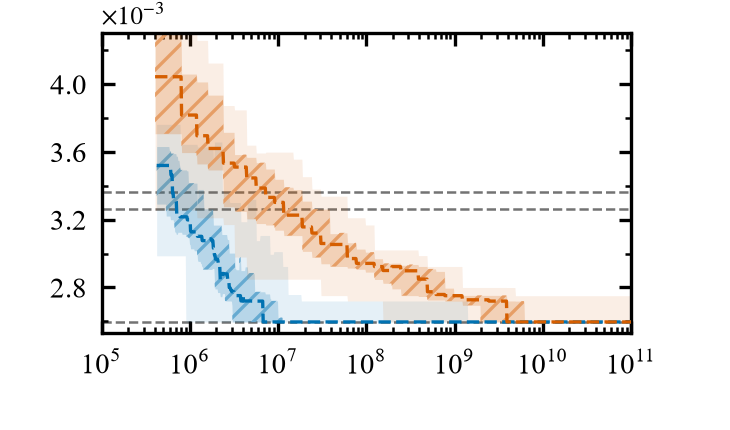

Processing EBBI: $p_\mathrm{search}=0.5\%$ (25/25)...          


Processing RS: $p_\mathrm{search}=0.5\%$ (25/25)...          


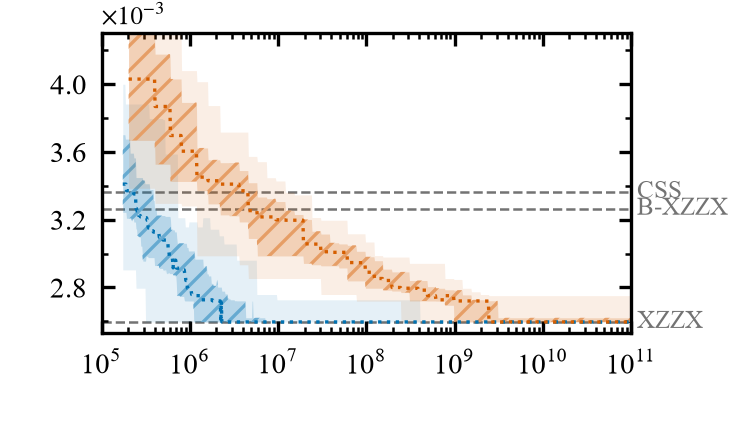

In [34]:
used_CD_folder_name="used_SC3_HBD"
# used_CD_folder_name="all_SC3_HBD"
kwargs = dict(
    used_CD_folder_name=used_CD_folder_name,
    references=references_sc3,
    xmin=1E5,
    xmax=1E11,
    ymax=4.3,
    ymin=2.53,
    y_power=-3,
    xlabel=False,
    shade=True,
    figsize=figsize,
)
fig, ax = plot_results(
    **kwargs,
    method_folder_names={
        "EBBI: $p_\\mathrm{search}=0.1\\%$": ("ebbi/SC3_HBD_MWPM_1x", EBBI_COLOR, '-'),
        "RS: $p_\\mathrm{search}=0.1\\%$": ("rs/SC3_HBD_MWPM_1x", RS_COLOR, '-'),
    },
    ylabel=True,
    references_text=False,
)
fig.savefig("outputs/comparizon/SC3_HBD_MWPM_p_0_1.pdf", bbox_inches="tight", transparent=True)
plt.show()
fig, ax = plot_results(
    **kwargs,
    method_folder_names={
        "EBBI: $p_\\mathrm{search}=0.25\\%$": ("ebbi/SC3_HBD_MWPM_2_5x", EBBI_COLOR, '--'),
        "RS: $p_\\mathrm{search}=0.25\\%$": ("rs/SC3_HBD_MWPM_2_5x", RS_COLOR, '--'),
    },
    ylabel=False,
    references_text=False,
)
fig.savefig("outputs/comparizon/SC3_HBD_MWPM_p_0_25.pdf", bbox_inches="tight", transparent=True)
plt.show()
fig, ax = plot_results(
    **kwargs,
    method_folder_names={
        "EBBI: $p_\\mathrm{search}=0.5\\%$": ("ebbi/SC3_HBD_MWPM_5x", EBBI_COLOR, ':'),
        "RS: $p_\\mathrm{search}=0.5\\%$": ("rs/SC3_HBD_MWPM_5x", RS_COLOR, ':'),
    },
    ylabel=False,
)
fig.savefig("outputs/comparizon/SC3_HBD_MWPM_p_0_5.pdf", bbox_inches="tight", transparent=True)
plt.show()

Processing EBBI: $p_\mathrm{search}=0.1\%$ (25/25)...          


Processing RS: $p_\mathrm{search}=0.1\%$ (25/25)...          


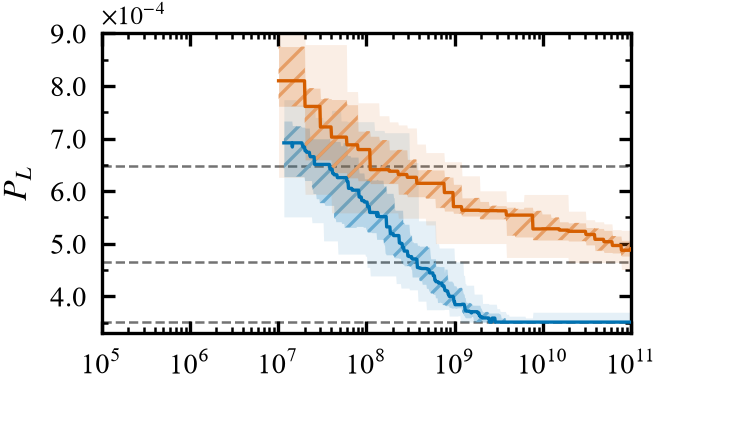

Processing EBBI: $p_\mathrm{search}=0.25\%$ (25/25)...          


Processing RS: $p_\mathrm{search}=0.25\%$ (25/25)...          


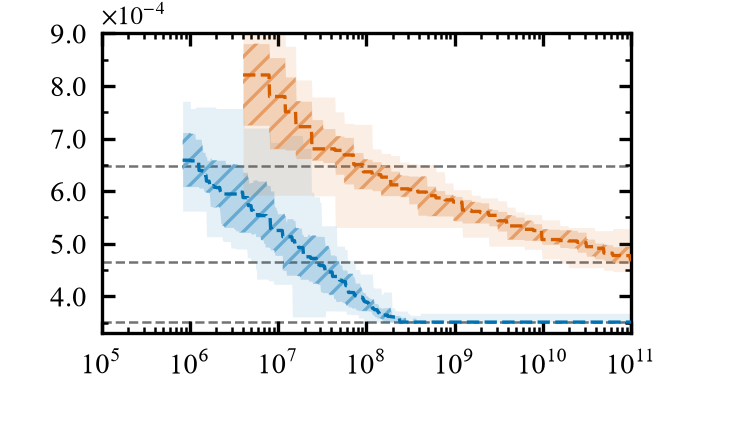

Processing EBBI: $p_\mathrm{search}=0.5\%$ (25/25)...          


Processing RS: $p_\mathrm{search}=0.5\%$ (25/25)...          


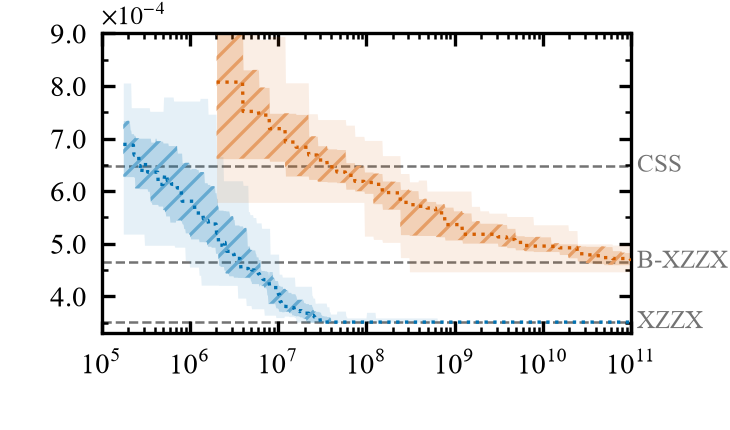

In [35]:
used_CD_folder_name="used_SC5_HBD"
kwargs = dict(
    used_CD_folder_name=used_CD_folder_name,
    references=references_sc5,
    xmin=1E5,
    xmax=1E11,
    ymax=9,
    ymin=3.3,
    y_power=-4,
    y_increments=1.0,
    xlabel=False,
    shade=True,
    figsize=figsize,
)
fig, ax = plot_results(
    **kwargs,
    method_folder_names={
        "EBBI: $p_\\mathrm{search}=0.1\\%$": ("ebbi/SC5_HBD_MWPM_1x", EBBI_COLOR, '-'),
        "RS: $p_\\mathrm{search}=0.1\\%$": ("rs/SC5_HBD_MWPM_1x", RS_COLOR, '-'),
    },
    ylabel=True,
    references_text=False,
)
fig.savefig("outputs/comparizon/SC5_HBD_MWPM_p_0_1.pdf", bbox_inches="tight", transparent=True)
plt.show()
fig, ax = plot_results(
    **kwargs,
    method_folder_names={
        "EBBI: $p_\\mathrm{search}=0.25\\%$": ("ebbi/SC5_HBD_MWPM_2_5x", EBBI_COLOR, '--'),
        "RS: $p_\\mathrm{search}=0.25\\%$": ("rs/SC5_HBD_MWPM_2_5x", RS_COLOR, '--'),
    },
    ylabel=False,
    references_text=False,
)
fig.savefig("outputs/comparizon/SC5_HBD_MWPM_p_0_25.pdf", bbox_inches="tight", transparent=True)
plt.show()
fig, ax = plot_results(
    **kwargs,
    method_folder_names={
        "EBBI: $p_\\mathrm{search}=0.5\\%$": ("ebbi/SC5_HBD_MWPM_5x", EBBI_COLOR, ':'),
        "RS: $p_\\mathrm{search}=0.5\\%$": ("rs/SC5_HBD_MWPM_5x", RS_COLOR, ':'),
    },
    ylabel=False,
)
fig.savefig("outputs/comparizon/SC5_HBD_MWPM_p_0_5.pdf", bbox_inches="tight", transparent=True)
plt.show()

Processing EBBI: $p_\mathrm{search}=0.1\%$ (25/25)...          


Processing RS: $p_\mathrm{search}=0.1\%$ (25/25)...          


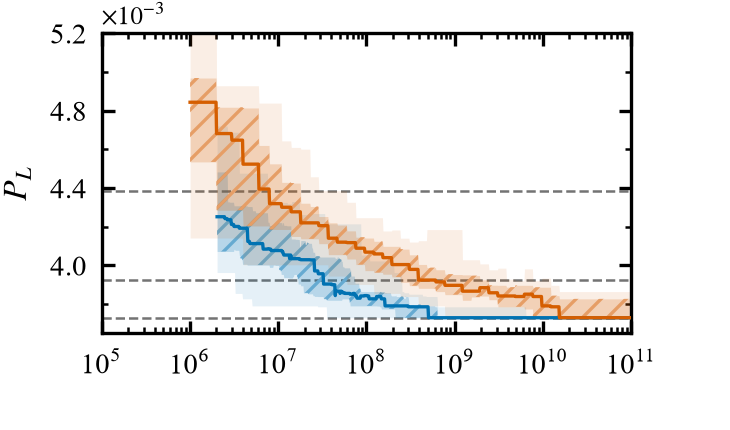

Processing EBBI: $p_\mathrm{search}=0.25\%$ (25/25)...          


Processing RS: $p_\mathrm{search}=0.25\%$ (25/25)...          


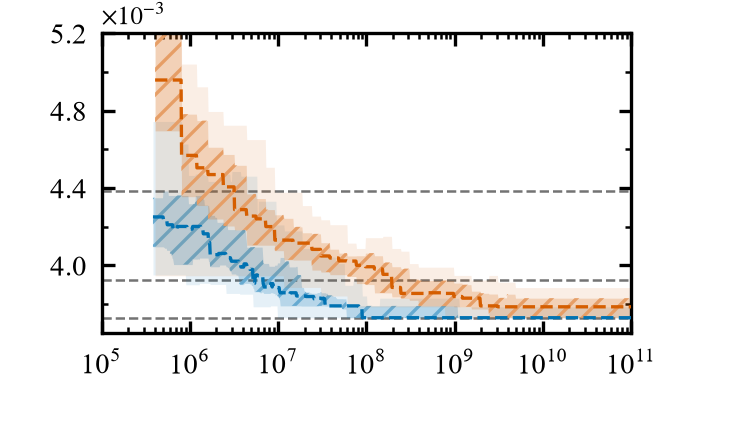

Processing EBBI: $p_\mathrm{search}=0.5\%$ (25/25)...          


Processing RS: $p_\mathrm{search}=0.5\%$ (25/25)...          


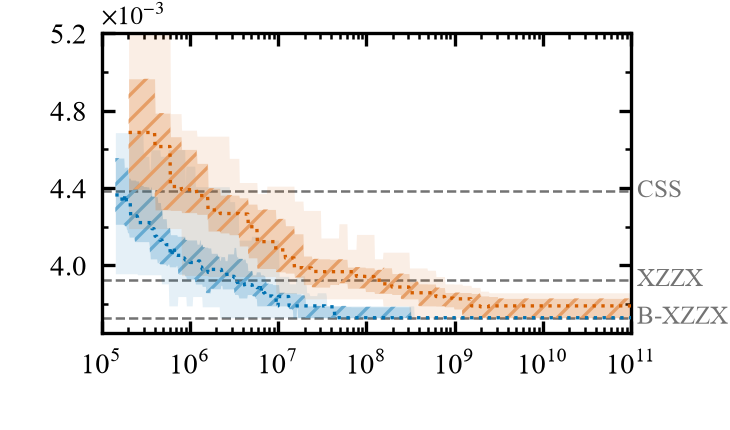

In [36]:
used_CD_folder_name="used_SC3_MHBD"
# used_CD_folder_name="all_SC3_MHBD"
kwargs = dict(
    used_CD_folder_name=used_CD_folder_name,
    references=references_sc3,
    xmin=1E5,
    xmax=1E11,
    ymax=5.2,
    ymin=3.65,
    y_power=-3,
    xlabel=False,
    shade=True,
    figsize=figsize,
)
fig, ax = plot_results(
    **kwargs,
    method_folder_names={
        "EBBI: $p_\\mathrm{search}=0.1\\%$": ("ebbi/SC3_MHBD_MWPM_1x", EBBI_COLOR, '-'),
        "RS: $p_\\mathrm{search}=0.1\\%$": ("rs/SC3_MHBD_MWPM_1x", RS_COLOR, '-'),
    },
    ylabel=True,
    references_text=False,
)
fig.savefig("outputs/comparizon/SC3_MHBD_MWPM_p_0_1.pdf", bbox_inches="tight", transparent=True)
plt.show()
fig, ax = plot_results(
    **kwargs,
    method_folder_names={
        "EBBI: $p_\\mathrm{search}=0.25\\%$": ("ebbi/SC3_MHBD_MWPM_2_5x", EBBI_COLOR, '--'),
        "RS: $p_\\mathrm{search}=0.25\\%$": ("rs/SC3_MHBD_MWPM_2_5x", RS_COLOR, '--'),
    },
    ylabel=False,
    references_text=False,
)
fig.savefig("outputs/comparizon/SC3_MHBD_MWPM_p_0_25.pdf", bbox_inches="tight", transparent=True)
plt.show()
fig, ax = plot_results(
    **kwargs,
    method_folder_names={
        "EBBI: $p_\\mathrm{search}=0.5\\%$": ("ebbi/SC3_MHBD_MWPM_5x", EBBI_COLOR, ':'),
        "RS: $p_\\mathrm{search}=0.5\\%$": ("rs/SC3_MHBD_MWPM_5x", RS_COLOR, ':'),
    },
    ylabel=False
)
fig.savefig("outputs/comparizon/SC3_MHBD_MWPM_p_0_5.pdf", bbox_inches="tight", transparent=True)
plt.show()

Processing EBBI: $p_\mathrm{search}=0.1\%$ (25/25)...          


Processing RS: $p_\mathrm{search}=0.1\%$ (25/25)...          


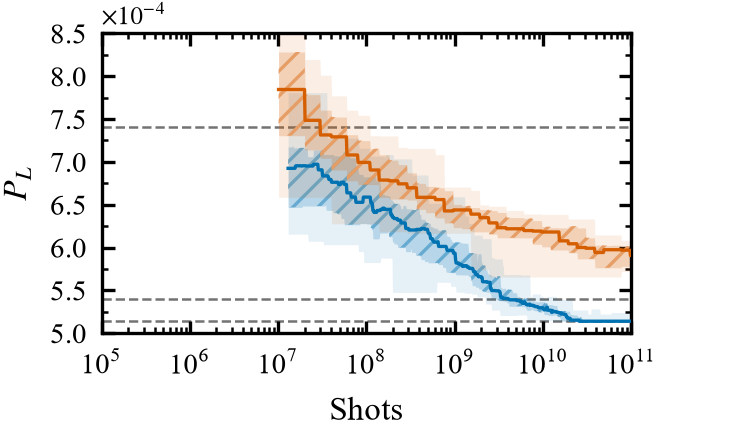

Processing EBBI: $p_\mathrm{search}=0.25\%$ (25/25)...          


Processing RS: $p_\mathrm{search}=0.25\%$ (25/25)...          


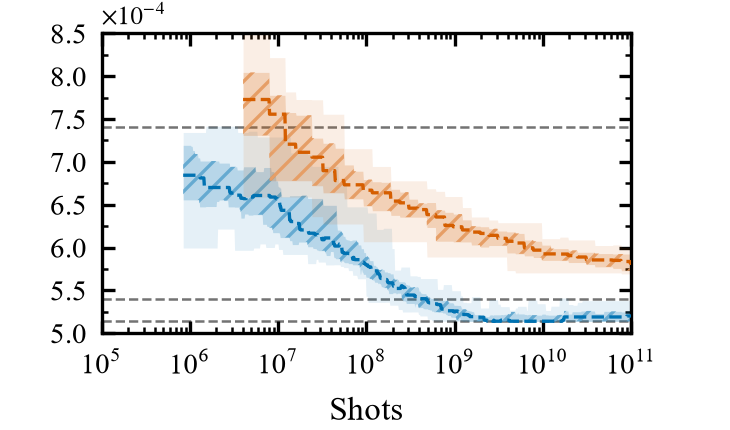

Processing EBBI: $p_\mathrm{search}=0.5\%$ (25/25)...          


Processing RS: $p_\mathrm{search}=0.5\%$ (25/25)...          


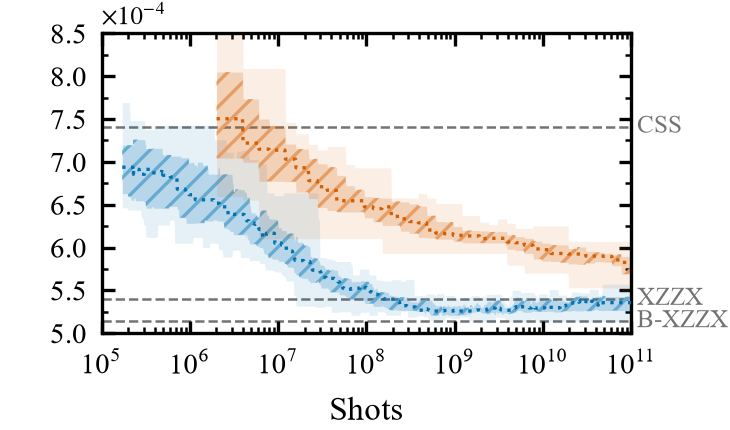

In [37]:
used_CD_folder_name="used_SC5_MHBD"
kwargs = dict(
    used_CD_folder_name=used_CD_folder_name,
    references=references_sc5,
    xmin=1E5,
    xmax=1E11,
    ymax=8.5,
    ymin=5,
    y_power=-4,
    y_increments=0.5,
    xlabel=True,
    shade=True,
    figsize=figsize,
)
fig, ax = plot_results(
    **kwargs,
    method_folder_names={
        "EBBI: $p_\\mathrm{search}=0.1\\%$": ("ebbi/SC5_MHBD_MWPM_1x", EBBI_COLOR, '-'),
        "RS: $p_\\mathrm{search}=0.1\\%$": ("rs/SC5_MHBD_MWPM_1x", RS_COLOR, '-'),
    },
    ylabel=True,
    references_text=False,
)
fig.savefig("outputs/comparizon/SC5_MHBD_MWPM_p_0_1.pdf", bbox_inches="tight", transparent=True)
plt.show()
fig, ax = plot_results(
    **kwargs,
    method_folder_names={
        "EBBI: $p_\\mathrm{search}=0.25\\%$": ("ebbi/SC5_MHBD_MWPM_2_5x", EBBI_COLOR, '--'),
        "RS: $p_\\mathrm{search}=0.25\\%$": ("rs/SC5_MHBD_MWPM_2_5x", RS_COLOR, '--'),
    },
    ylabel=False,
    references_text=False,
)
fig.savefig("outputs/comparizon/SC5_MHBD_MWPM_p_0_25.pdf", bbox_inches="tight", transparent=True)
plt.show()
fig, ax = plot_results(
    **kwargs,
    method_folder_names={
        "EBBI: $p_\\mathrm{search}=0.5\\%$": ("ebbi/SC5_MHBD_MWPM_5x", EBBI_COLOR, ':'),
        "RS: $p_\\mathrm{search}=0.5\\%$": ("rs/SC5_MHBD_MWPM_5x", RS_COLOR, ':'),
    },
    ylabel=False
)
fig.savefig("outputs/comparizon/SC5_MHBD_MWPM_p_0_5.pdf", bbox_inches="tight", transparent=True)
plt.show()

# Legend

In [5]:
legend_items = {
    "EBBI: $p_\\mathrm{search}=0.1\\%$": (EBBI_COLOR, "-"),
    "Random search: $p_\\mathrm{search}=0.1\\%$": (RS_COLOR, "-"),
    "EBBI: $p_\\mathrm{search}=0.25\\%$": (EBBI_COLOR, "--"),
    "Random search: $p_\\mathrm{search}=0.25\\%$": (RS_COLOR, "--"),
    "EBBI: $p_\\mathrm{search}=0.5\\%$": (EBBI_COLOR, ":"),
    "Random search: $p_\\mathrm{search}=0.5\\%$": (RS_COLOR, ":"),
}
save_legend(legend_items, "outputs/comparizon/legend.pdf", ncols=3, fontsize=7)

outputs/comparizon/legend.pdf: 3 column(s), 4.61 x 0.28 in


(np.float64(4.607777777777779), np.float64(0.28404839409722227))

# EBBI convergence table

How many of the EBBI runs end on the reference CD (the best CD of the experiment), and how
many sample it at some point. A run "ends" on the CD it holds at its last checkpoint below
`XMAX` shots, the same rule `plot_results` uses for `final_cd`. CDs are compared as exact
strings, so an equivalent CD under a different label is not counted.

Needs `\usepackage{multirow}`. Same layout as the runtime table in `tables.ipynb`: the
distance labels span their two noise models with `\multicolumn`.

In [7]:
XMAX = 1E11  # shot budget, matches xmax of the plots above
EOL = "\\" + "\\"  # LaTeX row terminator

# (distance, noise model) -> name of the reference CD in references_sc{d}
EXPERIMENTS = {
    (3, "HBD"):  "(XZZX)",
    (3, "MHBD"): "(B-XZZX)",
    (5, "HBD"):  "(XZZX)",
    (5, "MHBD"): "(B-XZZX)",
}
# method label -> results folder
METHODS = {
    "EBBI": "ebbi",
    "Random search":   "rs",
}
# p_search label -> folder suffix
P_SEARCH = {
    r"$0.1\%$":  "1x",
    r"$0.25\%$": "2_5x",
    r"$0.5\%$":  "5x",
}


def count_runs(method_folder_name: str, target_cd: str, xmax: float = XMAX):
    """(ended, reached, runs): runs whose final CD is `target_cd`, runs that sampled it at
    any checkpoint, and the total number of runs."""
    df = pd.read_csv(f"../results/{method_folder_name}/checkpoints.csv", dtype={"clifford_deformation": str})
    ended = reached = runs = 0
    for _, sdf in df.groupby("source_file", sort=False):
        runs += 1
        within = sdf[sdf["method_shots"] < xmax]
        ended += within["clifford_deformation"].values[-1] == target_cd
        reached += target_cd in set(sdf["clifford_deformation"])
    return ended, reached, runs


def convergence_table(latex: bool = True) -> pd.DataFrame:
    """(method, p_search) as rows, the (distance, noise model) experiments as columns, and
    each cell `ended / reached but not ended / never reached` over the runs of that experiment."""
    columns = {}
    for (distance, noise), cd_name in EXPERIMENTS.items():
        target_cd = (references_sc3 if distance == 3 else references_sc5)[cd_name[1:-1]]
        cells = []
        for folder in METHODS.values():
            for suffix in P_SEARCH.values():
                ended, reached, runs = count_runs(f"{folder}/SC{distance}_{noise}_MWPM_{suffix}", target_cd)
                cells.append(f"{ended}/{reached-ended}/{runs-reached}")
        label = f"Distance-{distance} surface code"
        columns[(label, noise, cd_name)] = cells
    p_labels = list(P_SEARCH) if latex else [k.strip("$").replace("\\", "") for k in P_SEARCH]
    index = pd.MultiIndex.from_product(
        [list(METHODS), p_labels],
        names=["Method", r"$p_\mathrm{search}$" if latex else "p_search"],
    )
    table = pd.DataFrame(columns, index=index)
    table.columns = pd.MultiIndex.from_tuples(table.columns)
    return table


def to_latex_convergence(table: pd.DataFrame, indent: str = " " * 4) -> str:
    r"""LaTeX tabular for the convergence table. The distance labels span their noise
    models with `\multicolumn`, the row labels span the three header rows (distance, noise
    model, reference CD) with `\multirow`, and each method label spans its p_search rows.
    Needs `\usepackage{multirow}`."""
    groups = {}
    for label, noise, cd_name in table.columns:
        groups.setdefault(label, []).append((noise, cd_name))

    spec = "cc|" + "|".join("c" * len(cols) for cols in groups.values())
    spans = [rf"\multicolumn{{{len(cols)}}}{{{'c|' if i < len(groups) - 1 else 'c'}}}{{{label}}}"
             for i, (label, cols) in enumerate(groups.items())]
    row_names = [rf"\multirow{{3}}{{*}}{{{name}}}" for name in table.index.names]

    lines = [rf"\begin{{tabular}}{{{spec}}}",
             indent + " & ".join([*row_names, *spans]) + " " + EOL,
             indent + " & ".join(["", "", *(noise for _, noise, _ in table.columns)]) + " " + EOL,
             indent + " & ".join(["", "", *(cd_name for _, _, cd_name in table.columns)]) + " " + EOL]
    for method in table.index.unique(level=0):
        rows = table.loc[method]
        lines.append(indent + r"\hline")
        for i, (p_search, row) in enumerate(rows.iterrows()):
            method_cell = rf"\multirow{{{len(rows)}}}{{*}}{{{method}}}" if i == 0 else ""
            lines.append(f"{indent}{method_cell} & {p_search} & " + " & ".join(row) + " " + EOL)
    lines.append(r"\end{tabular}")
    return "\n".join(lines)


convergence_table_df = convergence_table()
display(convergence_table(latex=False))
table = to_latex_convergence(convergence_table_df)
print(table)
with open("outputs/comparizon/ebbi_convergence_table.tex", "w") as f:
    f.write(table)

Distance-3 surface code           \
                                           HBD     MHBD   
                                        (XZZX) (B-XZZX)   
Method        p_search                                    
EBBI          0.1%                      25/0/0   25/0/0   
              0.25%                     25/0/0   24/0/1   
              0.5%                      25/0/0   25/0/0   
Random search 0.1%                      19/0/6   15/3/7   
              0.25%                     21/0/4   9/4/12   
              0.5%                      20/0/5   9/4/12   

                       Distance-5 surface code           
                                           HBD     MHBD  
                                        (XZZX) (B-XZZX)  
Method        p_search                                   
EBBI          0.1%                      23/2/0   16/2/7  
              0.25%                     22/2/1   6/6/13  
              0.5%                      25/0/0   0/2/23  
Random search 0.1%                      0/0/25   0/0/25  
              0.25%                     0/0/25   0/0/25  
              0.5%                      0/0/25   0/0/25

\begin{tabular}{cc|cc|cc}
    \multirow{3}{*}{Method} & \multirow{3}{*}{$p_\mathrm{search}$} & \multicolumn{2}{c|}{Distance-3 surface code} & \multicolumn{2}{c}{Distance-5 surface code} \\
     &  & HBD & MHBD & HBD & MHBD \\
     &  & (XZZX) & (B-XZZX) & (XZZX) & (B-XZZX) \\
    \hline
    \multirow{3}{*}{EBBI} & $0.1\%$ & 25/0/0 & 25/0/0 & 23/2/0 & 16/2/7 \\
     & $0.25\%$ & 25/0/0 & 24/0/1 & 22/2/1 & 6/6/13 \\
     & $0.5\%$ & 25/0/0 & 25/0/0 & 25/0/0 & 0/2/23 \\
    \hline
    \multirow{3}{*}{Random search} & $0.1\%$ & 19/0/6 & 15/3/7 & 0/0/25 & 0/0/25 \\
     & $0.25\%$ & 21/0/4 & 9/4/12 & 0/0/25 & 0/0/25 \\
     & $0.5\%$ & 20/0/5 & 9/4/12 & 0/0/25 & 0/0/25 \\
\end{tabular}
